In [58]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import precision_score, recall_score, f1_score
from imblearn.over_sampling import SMOTE
from sklearn.metrics import confusion_matrix

In [ ]:
#data cleaning
df = pd.read_csv("creditcard.csv")
df = df.drop_duplicates()
df = df.dropna()

In [ ]:
#feature engineering
scaler = StandardScaler()
df["scaled_amount"] = scaler.fit_transform(df[["Amount"]])

X = df.drop(columns=['Class', 'Amount']) # Class: 1 (Fraud), 0 (Normal)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
#smote
print("SMOTE ile sentetik Fraud verileri üretiliyor...")
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

SMOTE ile sentetik Fraud verileri üretiliyor...


In [ ]:
#model tanımları
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=200,
        solver='lbfgs',
        random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=30,
        max_depth=10,
        random_state=42,
        n_jobs=1
    ),
    "XGBoost": XGBClassifier(
        n_estimators=30,
        max_depth=6,
        eval_metric='logloss',
        random_state=42,
        n_jobs=1
    )
}

In [59]:
#model eğitimi
results = []
trained_models = {}

for name, model in models.items():
    print(f"{name} eğitiliyor...")

    # Modeli Eğit
    model.fit(X_train_resampled, y_train_resampled)

    # Sınıf Tahmini
    y_pred = model.predict(X_test)

    # Metrikleri Hesapla
    p = precision_score(y_test, y_pred, zero_division=0)
    r = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    results.append({
        "Model": name,
        "Precision": round(p, 4),
        "Recall": round(r, 4),
        "F1": round(f1, 4)
    })

    trained_models[name] = (model, y_pred)

Logistic Regression eğitiliyor...
Random Forest eğitiliyor...
XGBoost eğitiliyor...


In [ ]:
#tabloyu ekrana basma
comparison_df = pd.DataFrame(results)
print("-------model karsilastirma tablosu-------")
print(comparison_df.to_string(index=False))

-------model karsilastirma tablosu-------
              Model  Precision  Recall     F1
Logistic Regression     0.1001  0.8526 0.1792
      Random Forest     0.6124  0.8316 0.7054
            XGBoost     0.5166  0.8211 0.6341


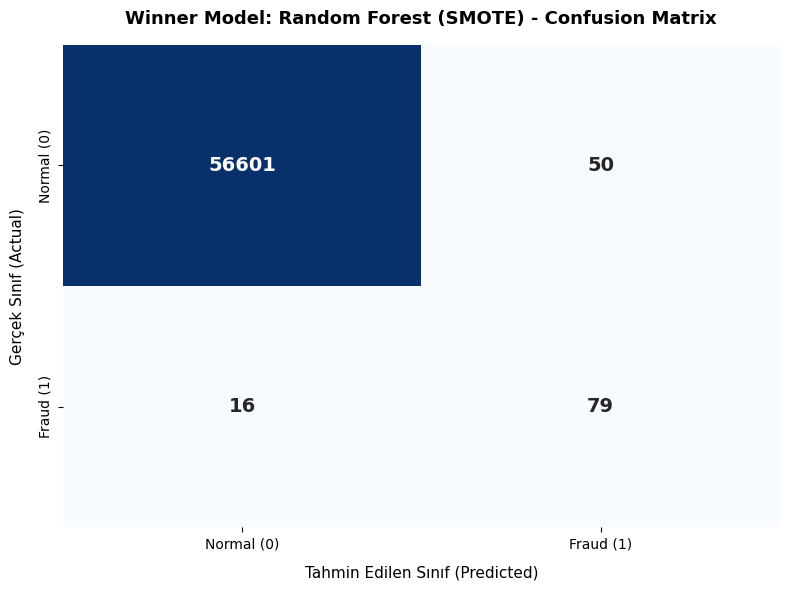

In [60]:
#en basarilisi random forest oldu
rf_model, rf_y_pred = trained_models["Random Forest"]
cm = confusion_matrix(y_test, rf_y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Normal (0)', 'Fraud (1)'],
    yticklabels=['Normal (0)', 'Fraud (1)'],
    cbar=False,
    annot_kws={"size": 14, "weight": "bold"}
)

plt.title('Winner Model: Random Forest (SMOTE) - Confusion Matrix', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Tahmin Edilen Sınıf (Predicted)', fontsize=11, labelpad=10)
plt.ylabel('Gerçek Sınıf (Actual)', fontsize=11, labelpad=10)
plt.tight_layout()
plt.show()